## pySCENIC Validation with Target AML Bulk RNA-seq

In [1]:
# Packages Required
import os
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib_venn import venn3_unweighted
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial import distance
from scipy.cluster import hierarchy
import scipy.stats as stats
from adjustText import adjust_text #version 0.8 - newer ones have error
import gseapy as gp
from gseapy import GSEA
from IPython.display import display
pd.options.display.max_columns = None
import pathlib

if not os.path.exists("plots"):
    os.makedirs("plots")

sc.settings.figdir = "plots"
sc.set_figure_params(scanpy=True, fontsize=10, dpi=180, dpi_save=500, frameon=False, format='png')

In [2]:
# Relevant Filepaths from pySCENIC
tcga_adata = './AML_ETO_TARGET_BEATAML.h5ad'
tcga_auc = './auc_mtx_TARGET_BAML.csv'
tcga_anno = './cellAnnot_TARGET_BAML.csv'

# Count and DE Results
counts_out = "./signature_groups_allocatoin_counts.csv"
groups_out = "./signature_groups_allocation.csv"
deseq = "./DESeq2_signature_Prenatal_vs_Postnatal.csv"
edger = "./edgeR_signature_Prenatal_vs_Postnatal.csv"
db1 = "/Users/jwhittle/GSEA/Human_genesets/c2.all.v2023.1.Hs.symbols.gmt"
db2 = "/Users/jwhittle/GSEA/Human_genesets/AML_drug_sensitivity.gmt"

# AutogeneS Results
autogenes = "/Users/jwhittle/bulk_deconvolution/AML_ETO_TCGA_v2/proportions_NuSVR.tsv"
target_outcomes = '../AML-ETO/pyscenic/gene_filtered/validation/TCGA/data/TARGET_outcomes.csv'
beataml_outcomes = '../AML-ETO/pyscenic/gene_filtered/validation/TCGA/data/BEATAML_outcomes.csv'

In [3]:
# Plotting Colour Palette Function
def palplot(pal, names, colors=None, size=1):
    n = len(pal)
    f, ax = plt.subplots(1, 1, figsize=(n * size, size))
    ax.imshow(np.arange(n).reshape(1, n),
              cmap=mpl.colors.ListedColormap(list(pal)),
              interpolation="nearest", aspect="auto")
    ax.set_xticks(np.arange(n) - .5)
    ax.set_yticks([-.5, .5])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    colors = n * ['k'] if colors is None else colors
    return f

# Assign significance function
def pval_to_asterisks(pvalue):
    if pvalue <= 0.0001:
        return "****"
    elif pvalue <= 0.001:
        return "***"
    elif pvalue <= 0.01:
        return "**"
    elif pvalue <= 0.05:
        return "*"
    return "ns"

In [4]:
# Plot Output Folder
save_name = 'aml_eto'
plots = 'plots/aml_eto/validation/'
if not os.path.exists("plots/aml_eto/validation"):
    os.makedirs("plots/aml_eto/validation")
sc.settings.figdir = "plots/aml_eto/validation"

## Initial Data Filtering

In [5]:
# Load AnnData
adata = sc.read_h5ad(tcga_adata)

# Define age groups
adata.obs["age_group"]="unknown"
subset = adata[adata.obs["age"]!="unknown"]
subset.obs["age"] = subset.obs["age"].astype('float')
group = subset[subset.obs["age"]>19]
sub = group.obs.index
adata.obs.loc[sub, 'age_group'] = "Adult"
group = subset[subset.obs["age"]<20]
group = group[group.obs["age"]>9]
sub = group.obs.index
adata.obs.loc[sub, 'age_group'] = "Adolescent"
group = subset[subset.obs["age"]<10]
sub = group.obs.index
adata.obs.loc[sub, 'age_group'] = "Pediatric"

/var/folders/32/8mghz1t14416wmmns0p1mgx80000gr/T/ipykernel_5185/1560442313.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  subset.obs["age"] = subset.obs["age"].astype('float')


In [6]:
# Select BM samples from diagnosis only - to best harmonise with AML scAtlas
cellAnnot = adata.obs
cellAnnot = cellAnnot[cellAnnot['specimen_type']!='Peripheral Blood NOS']
cellAnnot = cellAnnot[cellAnnot['tumor_descriptor']!='Recurrence']

auc_mtx = pd.read_csv(tcga_auc, index_col=0)
auc_mtx = auc_mtx.loc[auc_mtx.index.isin(cellAnnot.index)]

In [7]:
# Get list of used samples for source data
samp_list_df = cellAnnot[['sample',
           'specimen_type',
           'race',	
           'ethnicity',	
           'gender',
           'patient',
           'age',
           'age_group'
          ]]
samp_list_df['type'] = 'bulk RNA-seq'
samp_list_df.to_csv('sample_list.csv')

/var/folders/32/8mghz1t14416wmmns0p1mgx80000gr/T/ipykernel_5185/129762085.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  samp_list_df['type'] = 'bulk RNA-seq'


In [8]:
# Find Columns with All 0 Values to Filter Out
remove = list(auc_mtx.loc[:, ~auc_mtx.any()].columns)
print(remove)
auc_mtx = auc_mtx.drop(remove, axis=1)

['E2F8_(+)', 'FEV_(+)', 'HES7_(+)', 'POU3F2_(+)', 'SHOX2_(+)']


## Visualise Pre/Post-Natal Signature Regulons

In [9]:
# Set colourmap
age_cm = {
    'Adult':'#de8f05ff',
    'Pediatric':'#0173b2ff',
    'Adolescent':'#029e73ff'
}
age_cm = dict(sorted(age_cm.items()))

prenatal = ['TRIM28_(+)','CTCF_(+)','RAD21_(+)','SOX4_(+)','TAL1_(+)','MYB_(+)','FOXN3_(+)',
            'JUND_(+)','BCLAF1_(+)','ZBTB7A_(+)','IKZF1_(+)','MAZ_(+)','REST_(+)','YY1_(+)',
            'CUX1_(+)','KDM5A_(+)']
postnatal = ['YBX1_(+)','ENO1_(+)','HDAC2_(+)','GATA1_(+)','POLE3_(+)','TFDP1_(+)','MYBL2_(+)',
             'E2F4_(+)','KLF1_(+)','IRF1_(+)','STAT1_(+)','IRF7_(+)','MAFF_(+)','ATF4_(+)','TAGLN2_(+)',
             'SPI1_(+)','KLF2_(+)']
key_regulons = prenatal + postnatal

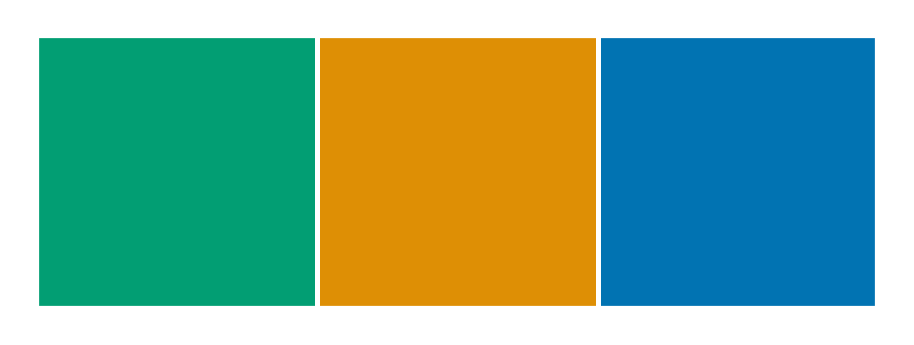

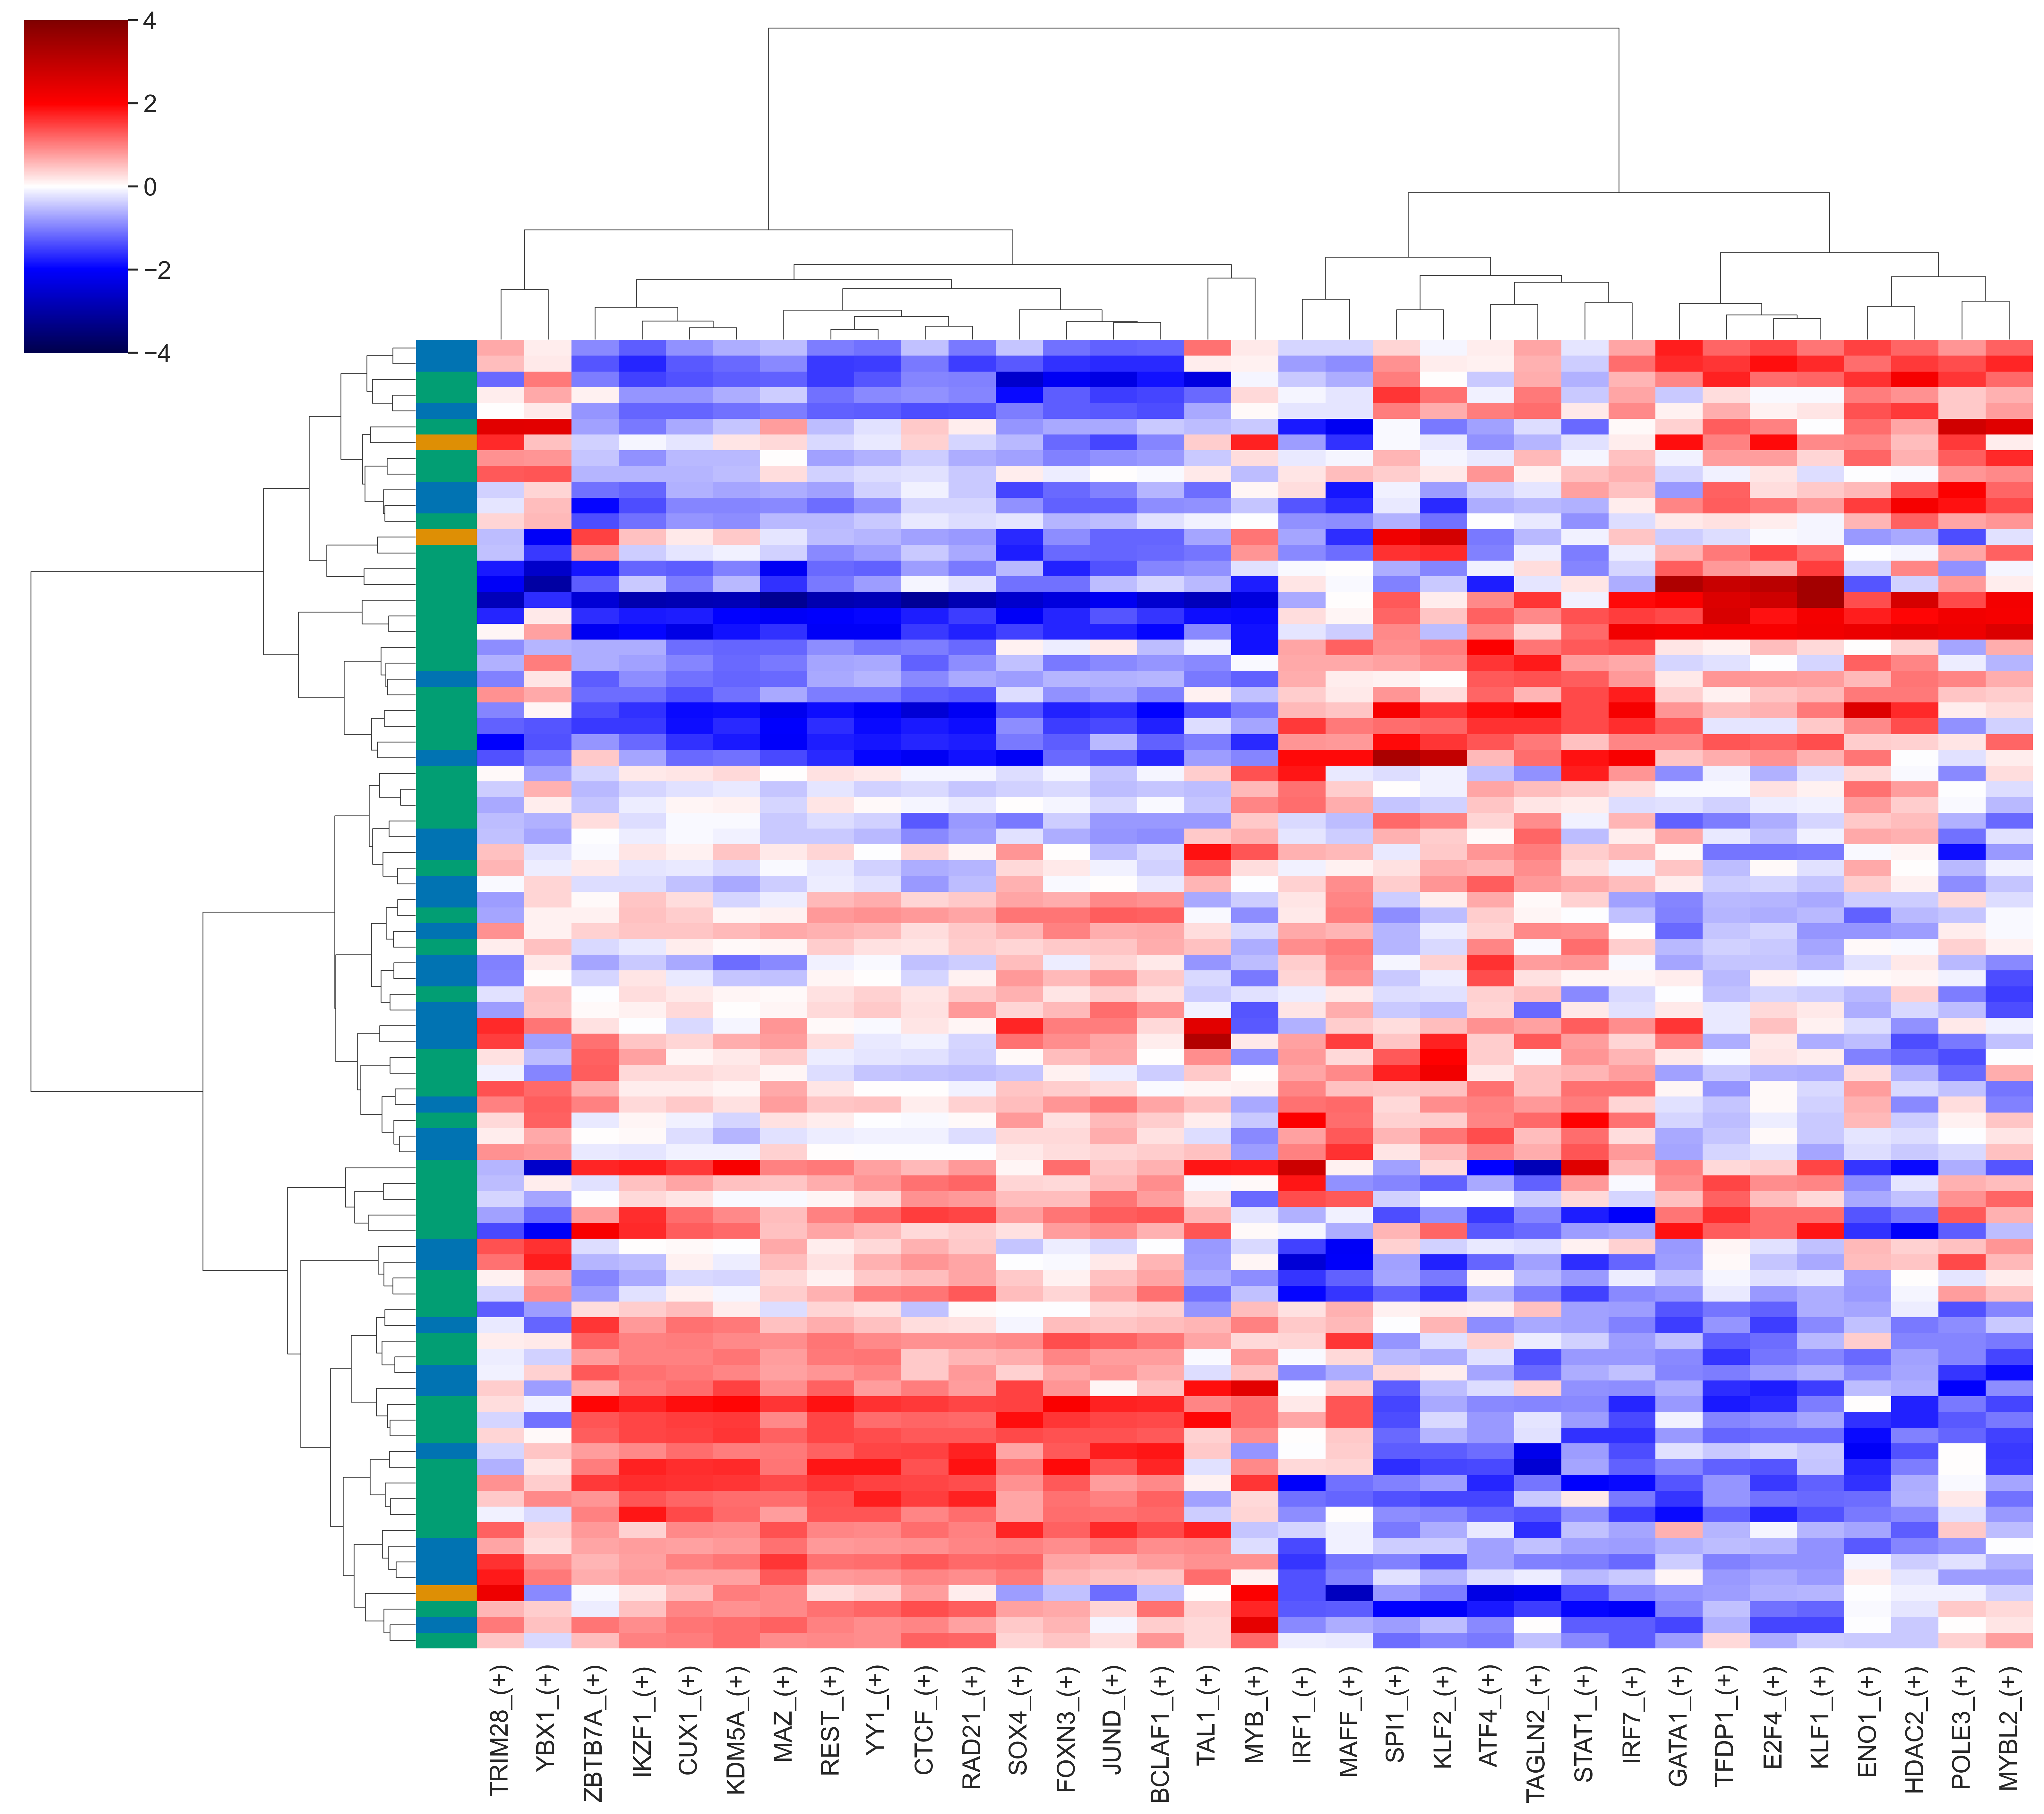

In [10]:
# Create Z Score matrix to enable comparison between regulons
auc_mtx_Z = pd.DataFrame( index=auc_mtx.index )
for col in list(auc_mtx.columns):
    auc_mtx_Z[ col ] = ( auc_mtx[col] - auc_mtx[col].mean()) / auc_mtx[col].std(ddof=0)

# Create heatmap
cats = sorted(list(set(cellAnnot['age_group'])))
age_colours = []
for key in age_cm:
    age_colours.append(age_cm[key])
colors = sns.color_palette(age_colours,n_colors=len(cats) )
colorsd = dict( zip( cats, colors ))
colormap2 = [ colorsd[x] for x in cellAnnot['age_group'] ]

sns.set()
sns.set(font_scale=0.8)
fig = palplot( colors, cats, size=1.0)
plt.savefig(plots + "TCGA_heatmap_legend_" + save_name + ".png", dpi=600, bbox_inches = "tight")

sns.set(font_scale=1.4)
#plt.rcParams.update({'font.weight': 'bold'})
g = sns.clustermap(auc_mtx_Z[key_regulons], annot=False,  square=False, 
                   linecolor='gray', method='ward',
                   yticklabels=False, xticklabels=True, vmin=-4, vmax=4, row_colors=[colormap2],
    cmap='seismic', figsize=(18,16) )
g.cax.set_visible(True)
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.set_xlabel('')
plt.savefig(plots + "TCGA_heatmap_" + save_name + ".png", dpi=600, bbox_inches = "tight")

## Review Regulon Signature Clusters

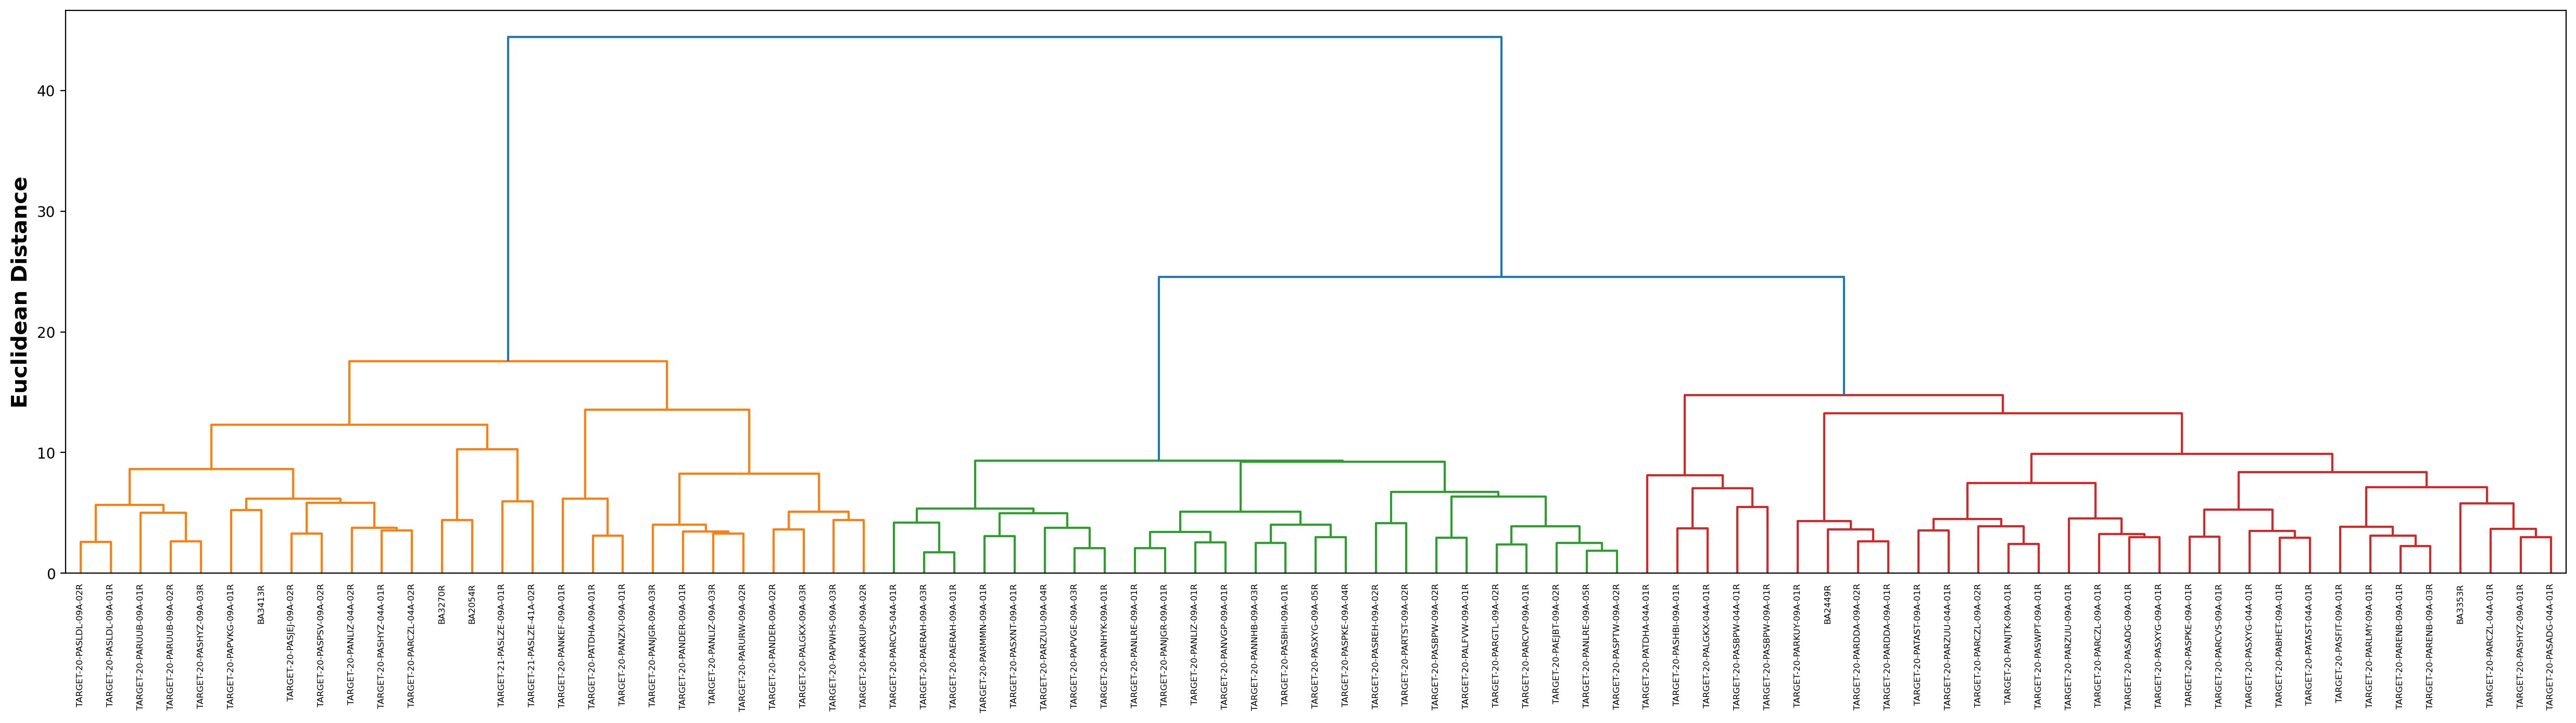

In [11]:
# Select from clustermap
data = auc_mtx_Z[key_regulons]
reordered_rows = data.index[g.dendrogram_row.reordered_ind]
reordered_cols = data.columns[g.dendrogram_col.reordered_ind]
clustered_data = data.loc[reordered_rows,reordered_cols]

# Select Sample Clusters for Each Signature
# Plot Sample Cluster Dendogram
Z = g.dendrogram_row.linkage

plt.style.use('default')
#plt.rcParams.update({'font.weight': 'bold'})
plt.figure(figsize=(25, 6))
#plt.title('Hierarchical Clustering', fontsize=20)
plt.xlabel('')
plt.ylabel('Euclidean Distance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.grid(False)

dend = dendrogram(
    Z,
    labels=np.array(data.index),
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=6.,
    color_threshold=18.0
)

plt.savefig(plots + "heatmap_dendrogram_" + save_name + ".png", dpi=600, bbox_inches = "tight")

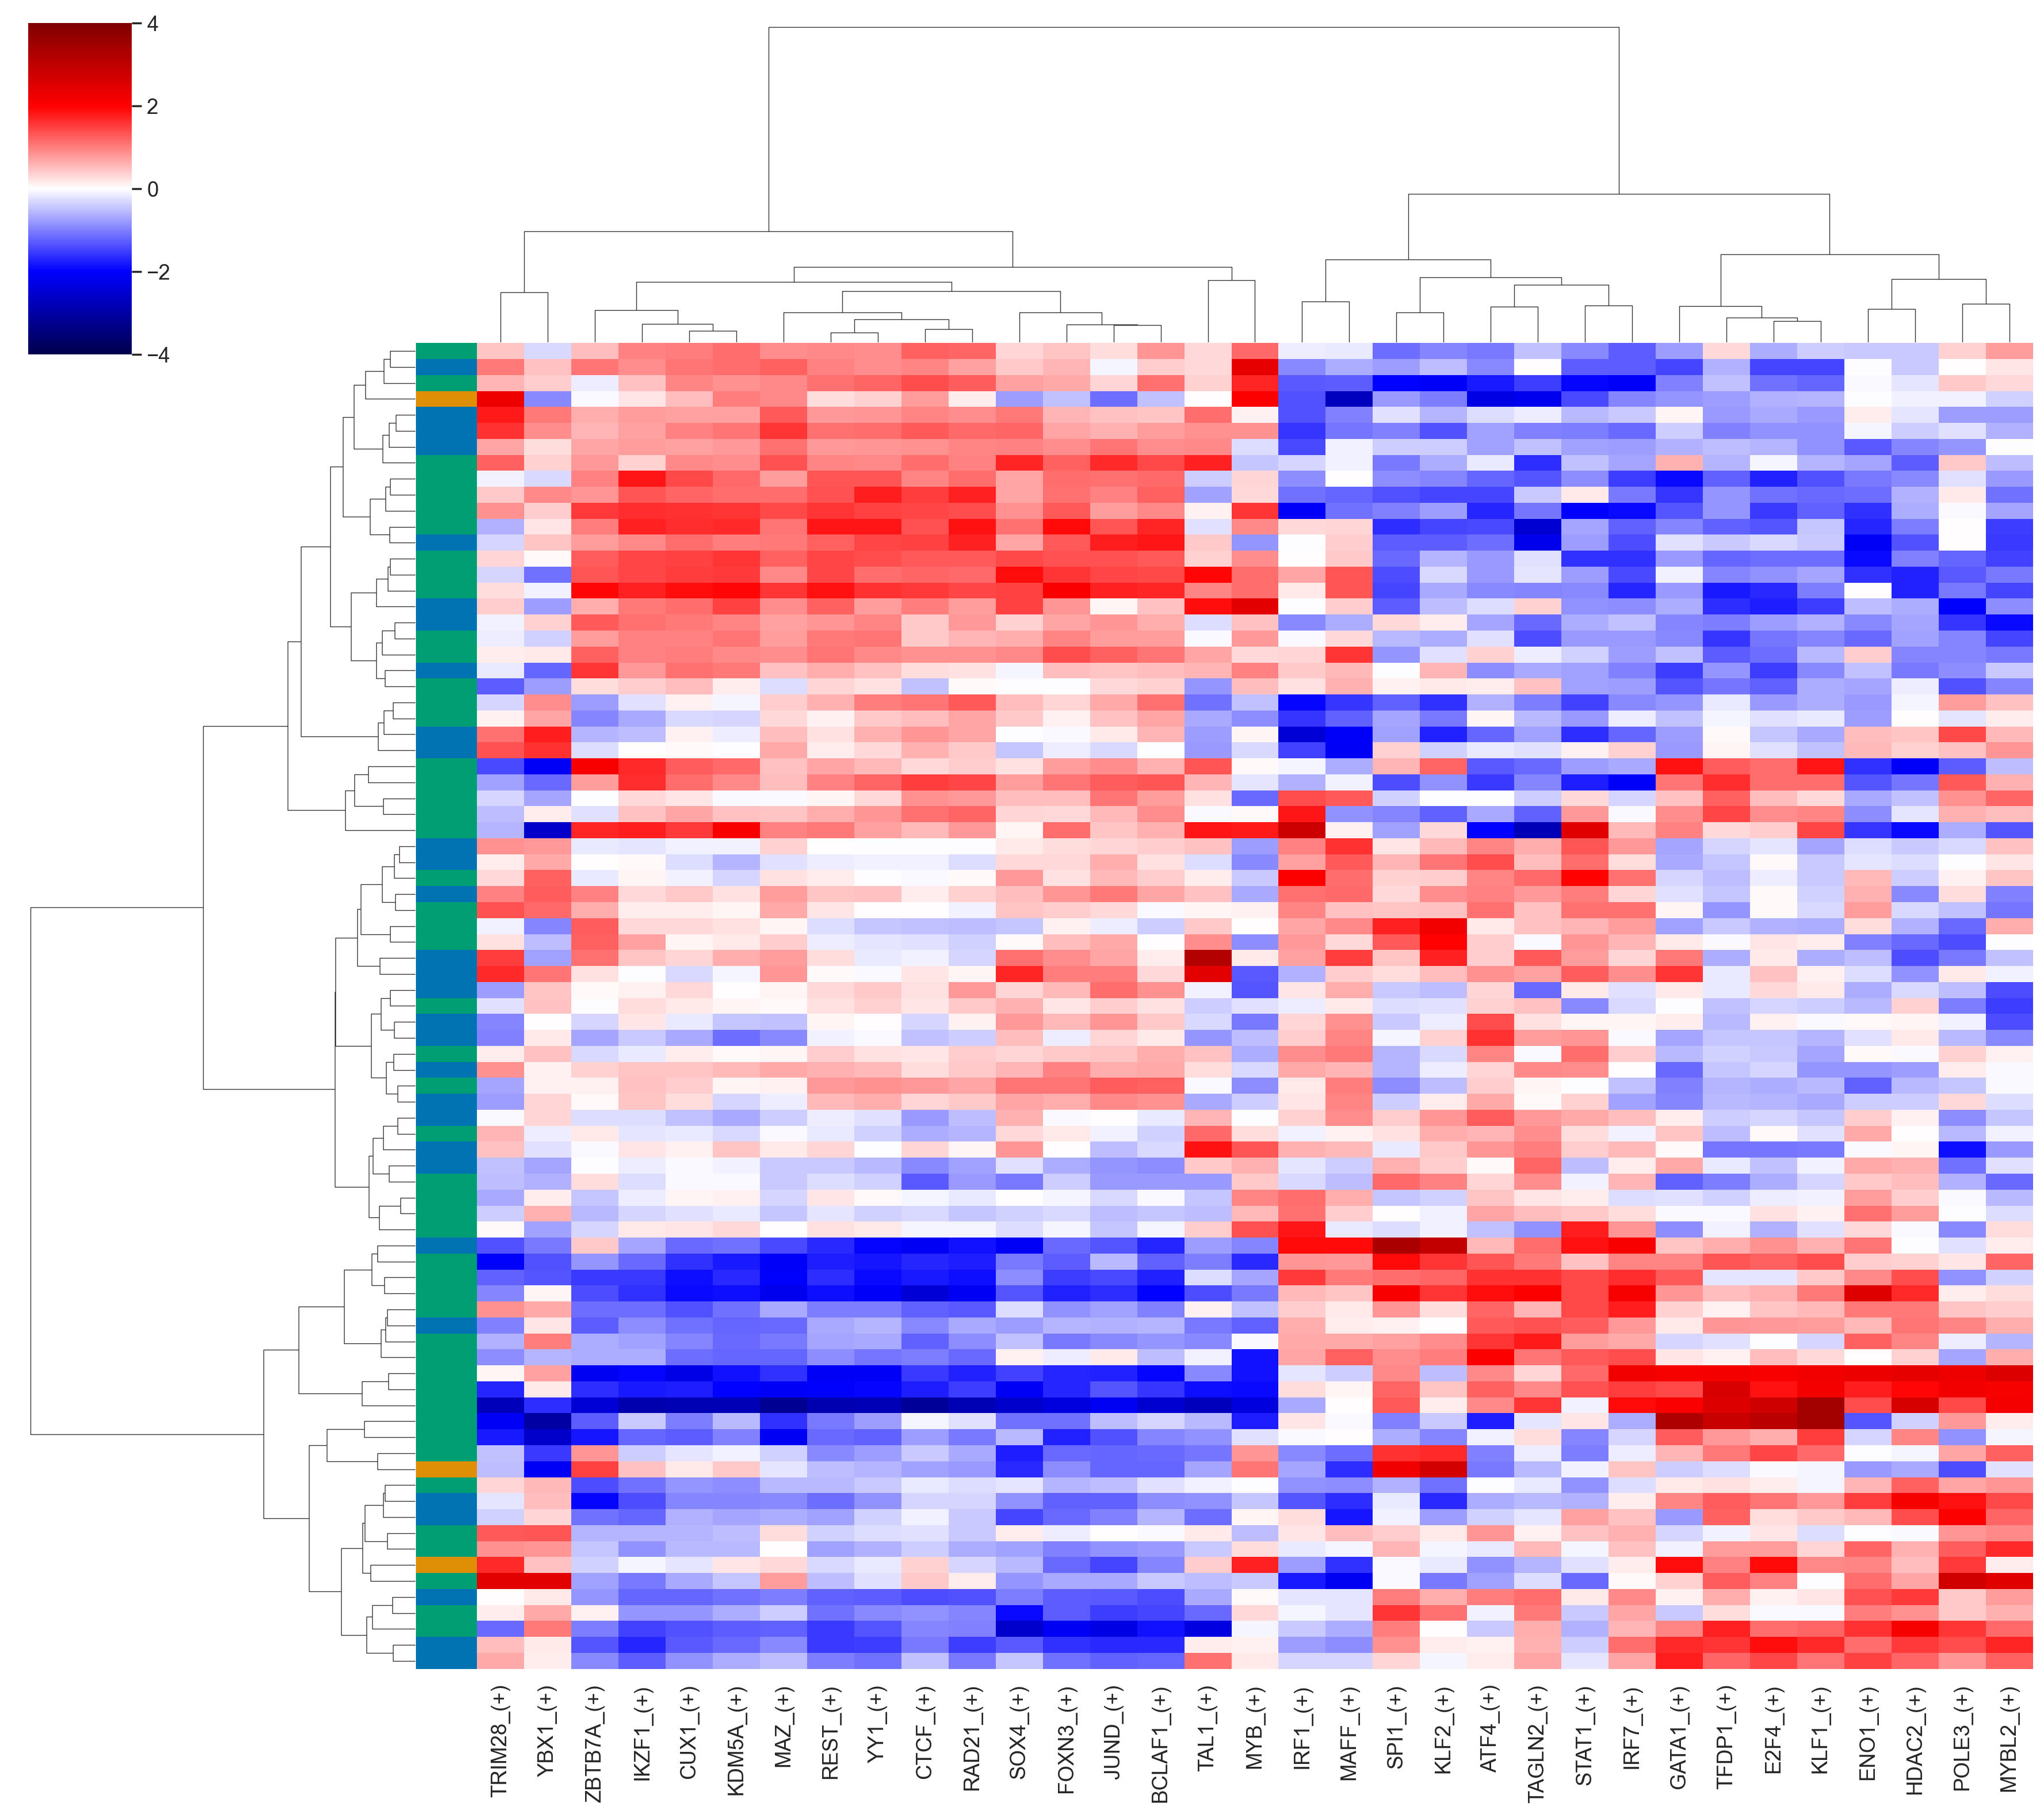

In [12]:
# Adjust Y Axis to match dendrogram
sns.set(font_scale=1.2)
g = sns.clustermap(auc_mtx_Z[key_regulons], annot=False,  square=False, 
                   linecolor='gray', method='ward',
                   yticklabels=False, xticklabels=True, 
                   vmin=-4, vmax=4, row_colors=[colormap2],
                   cmap='seismic', figsize=(18,16) )

g.cax.set_visible(True)
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.invert_yaxis()
g.ax_row_dendrogram.invert_yaxis()
g.ax_row_colors.invert_yaxis()

plt.savefig(plots + "TCGA_heatmap_" + save_name + ".png", dpi=600, bbox_inches = "tight")

## Assign Sample Groups

In [13]:
# Get the leaf labels and their corresponding branch colours
leaf_labels = dend['ivl']
leaf_colors = dend['leaves_color_list']

# Combine into a DataFrame
color_table = pd.DataFrame({
    'Sample': leaf_labels,
    'Cluster': leaf_colors
})
color_table = color_table.set_index('Sample')

In [14]:
# Export Signature Groups for DE Analysis
color_identity_map = {
    'C1': 'Postnatal',
    'C2': 'Intermediate',
    'C3': 'Prenatal',
}

color_table['Identity'] = color_table['Cluster'].map(color_identity_map)

color_table.to_csv('signature_groups_allocation.csv')

# Count Mtx
adata_filtered = adata[color_table.index, :]

count_matrix = adata_filtered.X
count_matrix_df = pd.DataFrame(count_matrix.toarray(), columns=adata_filtered.var_names, index=adata_filtered.obs_names)

count_matrix_df.to_csv('signature_groups_allocation_counts.csv')

## Compare Signature Clusters

### Differential Gene Expression

In [15]:
# Get Regulon TFs
tfs = []
for r in key_regulons:
    tf = r.replace("_(+)", "")
    if tf in adata.var_names:
        tfs.append(tf)

# Compare DE Gene Results
de_dict = {}

['KDM5A', 'RAD21', 'BCLAF1', 'TAL1', 'YY1', 'STAT1', 'REST']
['ENO1', 'SPI1', 'MYBL2', 'KLF2', 'YBX1', 'TFDP1', 'IRF7', 'TAGLN2', 'JUND']


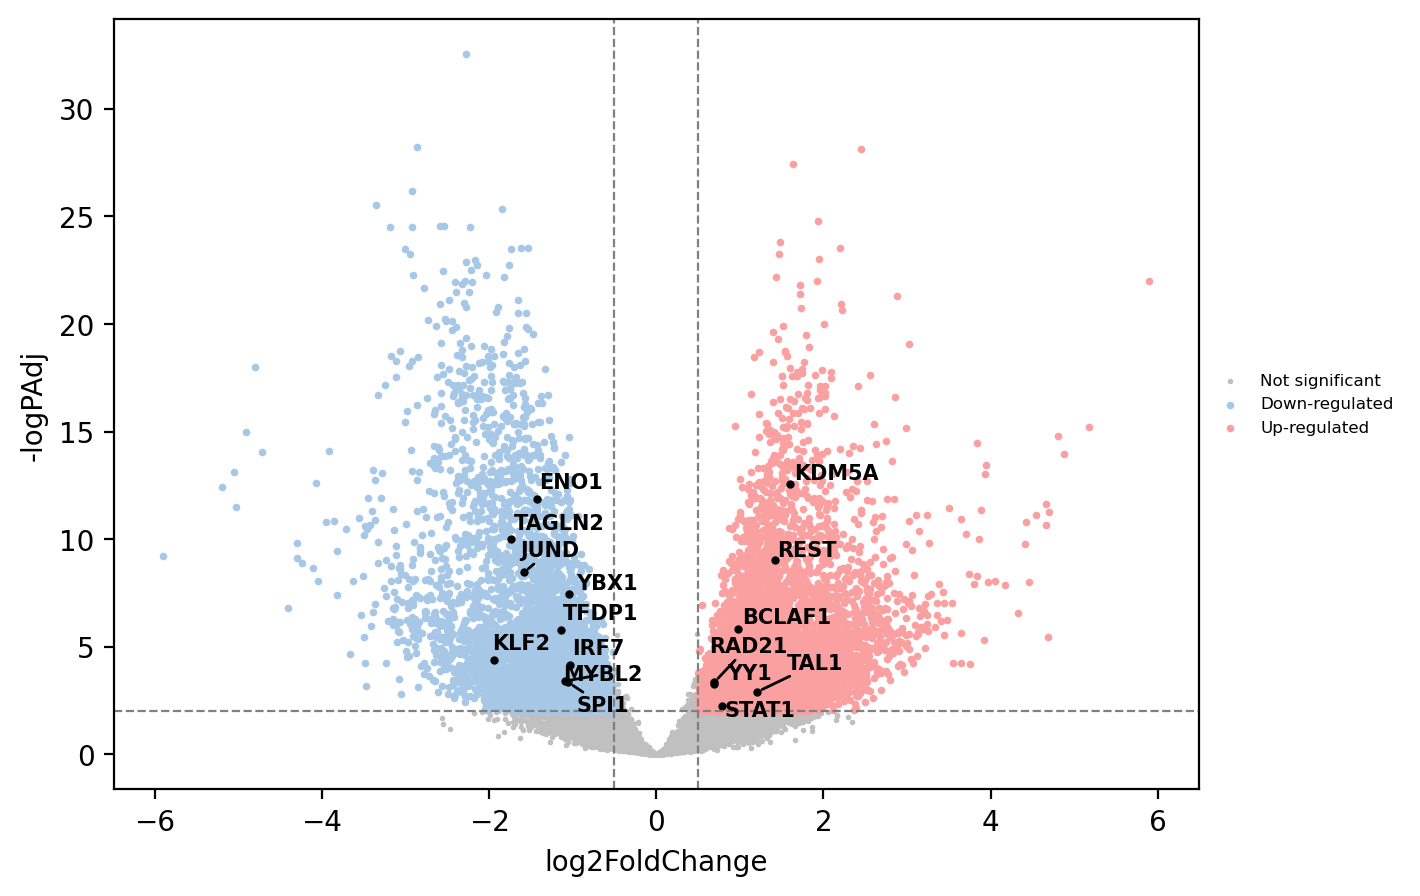

In [16]:
# #### DESeq2 - Run in RStudio
ds = pd.read_csv(deseq, index_col=0)

plt.style.use('default')
plt.figure(figsize=(7, 5))
plt.scatter(x=ds['log2FoldChange'],y=ds['padj'].apply(lambda x:-np.log10(x)),s=1,label="Not significant",color='#C0C0C0')

# highlight down- or up- regulated genes (and add to dict for later)
down = ds[(ds['log2FoldChange']<=-0.5)&(ds['padj']<=0.01)]
de_dict['deseq2_down'] = list(down.index)
up = ds[(ds['log2FoldChange']>=0.5)&(ds['padj']<=0.01)]
de_dict['deseq2_up'] = list(up.index)

plt.scatter(x=down['log2FoldChange'],y=down['padj'].apply(lambda x:-np.log10(x)),s=3,label="Down-regulated",color="#A7C7E7")
plt.scatter(x=up['log2FoldChange'],y=up['padj'].apply(lambda x:-np.log10(x)),s=3,label="Up-regulated",color="#FAA0A0")

# plot gene names for selected genes
genes_up = list( set(tfs) & set(up.index) )
print(genes_up)
texts=[]
for i,r in up.loc[genes_up].iterrows():
    texts.append(plt.text(x=r['log2FoldChange'],y=-np.log10(r['padj']),
                          fontsize=7.5, s=i, fontweight='bold'))
    plt.scatter(x=r['log2FoldChange'],y=-np.log10(r['padj']),s=4,color="black")
adjust_text(texts,arrowprops=dict(arrowstyle="-", color='black', lw=1))

genes_down = list( set(tfs) & set(down.index) )
print(genes_down)
texts=[]
for i,r in down.loc[genes_down].iterrows():
    texts.append(plt.text(x=r['log2FoldChange'],y=-np.log10(r['padj']),
                          fontsize=7.5, s=i, fontweight='bold'))
    plt.scatter(x=r['log2FoldChange'],y=-np.log10(r['padj']),s=4,color="black")
adjust_text(texts,arrowprops=dict(arrowstyle="-", color='black', lw=1))

plt.xlabel("log2FoldChange")
plt.ylabel("-logPAdj")
plt.axvline(-0.5,color="grey",linestyle="--",lw=0.8)
plt.axvline(0.5,color="grey",linestyle="--", lw=0.8)
plt.axhline(-np.log10(0.01),color="grey",linestyle="--", lw=0.8)
plt.legend(title="",
           fontsize=6,
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1),
           frameon=False)
plt.savefig(plots + "volcano_prenatal_vs_postnatal_DESeq2.png", format='png', bbox_inches='tight')

['KDM5A', 'RAD21', 'BCLAF1', 'TAL1', 'YY1', 'REST']
['ENO1', 'SPI1', 'MYBL2', 'KLF2', 'YBX1', 'TFDP1', 'IRF7', 'TAGLN2', 'JUND']


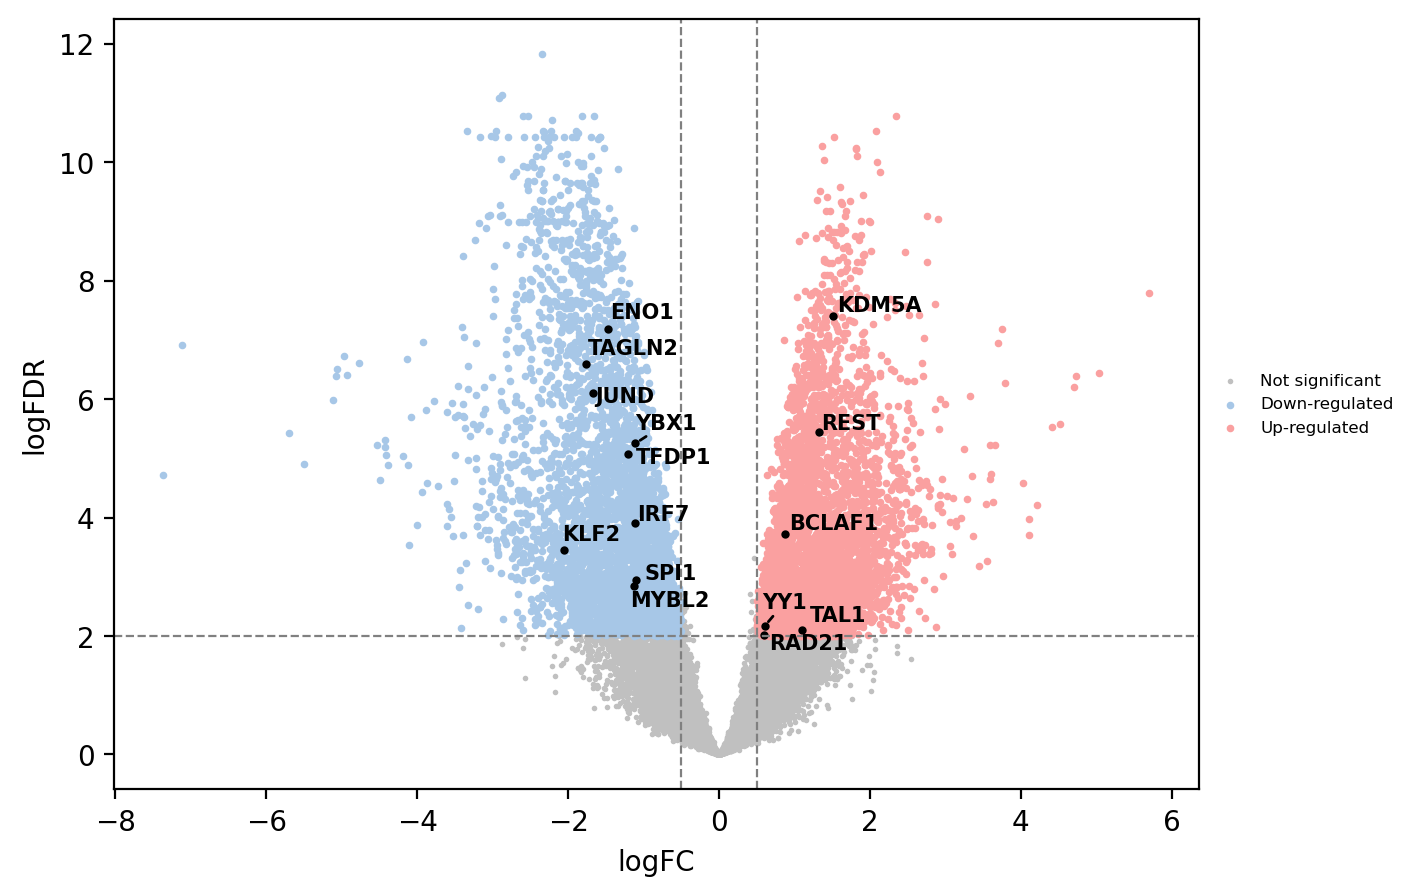

In [17]:
# #### EdgeR - Run in RStudio
ds = pd.read_csv(edger, index_col=0)

plt.style.use('default')
plt.figure(figsize=(7, 5))
plt.scatter(x=ds['logFC'],y=ds['FDR'].apply(lambda x:-np.log10(x)),s=1,label="Not significant",color='#C0C0C0')

# highlight down- or up- regulated genes
down = ds[(ds['logFC']<=-0.5)&(ds['FDR']<=0.01)]
de_dict['edger_down'] = list(down.index)
up = ds[(ds['logFC']>=0.5)&(ds['FDR']<=0.01)]
de_dict['edger_up'] = list(up.index)

plt.scatter(x=down['logFC'],y=down['FDR'].apply(lambda x:-np.log10(x)),s=3,label="Down-regulated",color="#A7C7E7")
plt.scatter(x=up['logFC'],y=up['FDR'].apply(lambda x:-np.log10(x)),s=3,label="Up-regulated",color="#FAA0A0")

# plot gene names for selected genes
genes_up = list( set(tfs) & set(up.index) )
print(genes_up)
texts=[]
for i,r in up.loc[genes_up].iterrows():
    texts.append(plt.text(x=r['logFC'],y=-np.log10(r['FDR']),
                          fontsize=7.5, s=i, fontweight='bold'))
    plt.scatter(x=r['logFC'],y=-np.log10(r['FDR']),s=4,color="black")
adjust_text(texts,arrowprops=dict(arrowstyle="-", color='black', lw=1))

genes_down = list( set(tfs) & set(down.index) )
print(genes_down)
texts=[]
for i,r in down.loc[genes_down].iterrows():
    texts.append(plt.text(x=r['logFC'],y=-np.log10(r['FDR']),
                          fontsize=7.5, s=i, fontweight='bold'))
    plt.scatter(x=r['logFC'],y=-np.log10(r['FDR']),s=4,color="black")
adjust_text(texts,arrowprops=dict(arrowstyle="-", color='black', lw=1))

plt.xlabel("logFC")
plt.ylabel("logFDR")
plt.axvline(-0.5,color="grey",linestyle="--",lw=0.8)
plt.axvline(0.5,color="grey",linestyle="--", lw=0.8)
plt.axhline(-np.log10(0.01),color="grey",linestyle="--", lw=0.8)
plt.legend(title="",
           fontsize=6,
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1),
           frameon=False)
plt.savefig(plots + "volcano_prenatal_vs_postnatal_edgeR.png", format='png', bbox_inches='tight')

/Users/jwhittle/miniforge3/envs/scanpy-env/lib/python3.12/site-packages/matplotlib_venn/_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


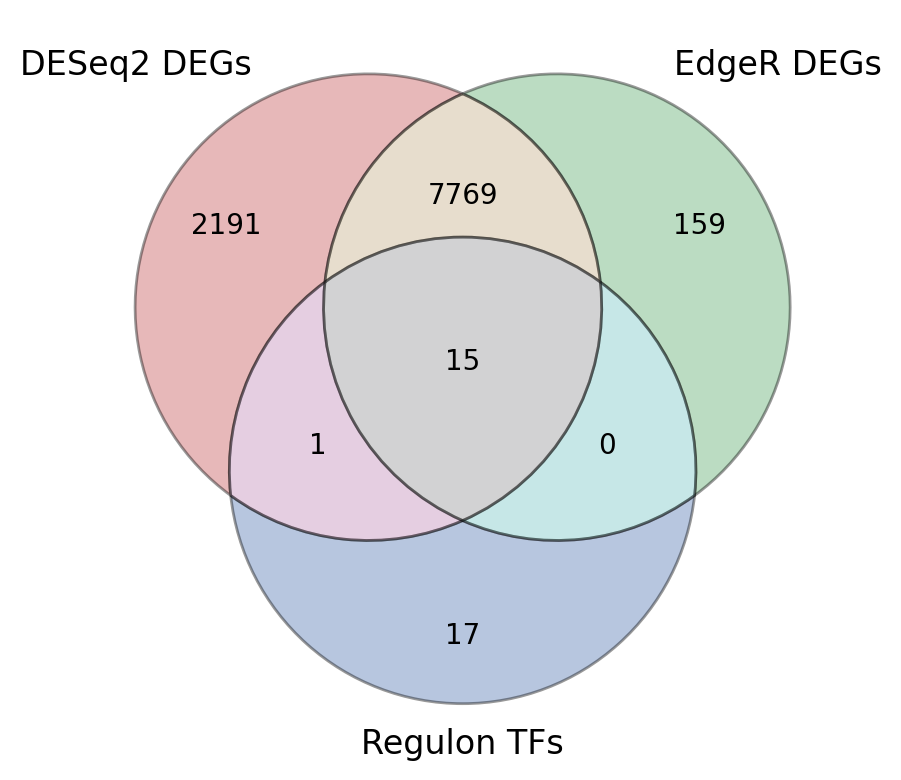

In [18]:
# Compare DE Methods

# Define the venn sets
set1 = set(de_dict['deseq2_down'] + de_dict['deseq2_up'])
set2 = set(de_dict['edger_down'] + de_dict['edger_up'])
tfs = []
for r in key_regulons:
    tf = r.replace("_(+)", "")
    if tf in adata.var_names:
        tfs.append(tf)
set3 = set(tfs)

v = venn3_unweighted([set1, set2, set3], ('DESeq2 DEGs', 'EdgeR DEGs', 'Regulon TFs'))

for patch in v.patches:
    if patch:
        patch.set_edgecolor('black')
        patch.set_linewidth(1) 

plt.savefig(plots + "venn_degs_ol.png", format='png', bbox_inches='tight')

In [19]:
common = set1.intersection(set2, set3)
print(common)

{'ENO1', 'SPI1', 'KDM5A', 'RAD21', 'MYBL2', 'KLF2', 'YBX1', 'TFDP1', 'BCLAF1', 'TAL1', 'IRF7', 'YY1', 'TAGLN2', 'JUND', 'REST'}


### GSEA

In [20]:
# Get background genes
bg = list(set(adata.var.index))

# Prepare gene rank
down = ds[(ds['logFC']<=-0.5)&(ds['FDR']<=0.01)]
up = ds[(ds['logFC']>=0.5)&(ds['FDR']<=0.01)]
gene_rank = pd.concat([up,down])

gene_rank = gene_rank.sort_values('logFC', ascending=False)
gene_rank = gene_rank[['logFC']]

<Figure size 400x300 with 0 Axes>

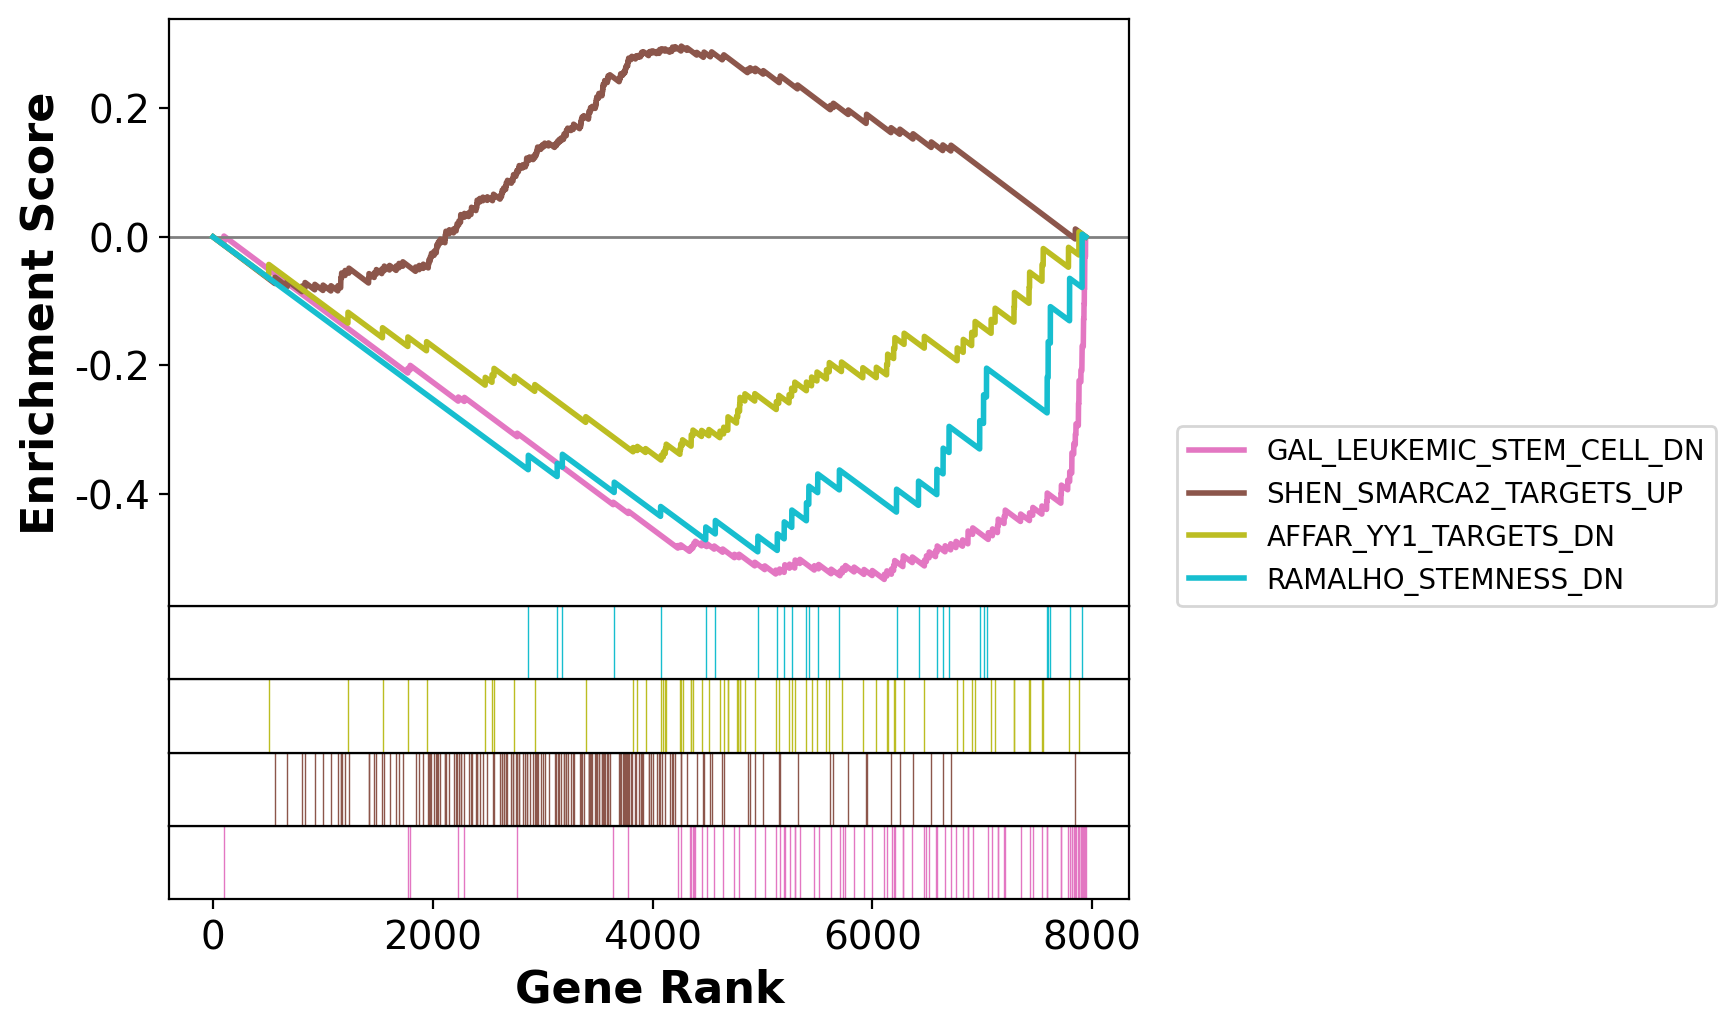

In [21]:
# Select pathways to plot
db = db1
res = gp.prerank(rnk=gene_rank, gene_sets=db, background=bg)
filtered_results = res.res2d[res.res2d['FDR q-val']<0.05]
path = pathlib.Path(db)
path = path.stem

terms = ['GAL_LEUKEMIC_STEM_CELL_DN', 'SHEN_SMARCA2_TARGETS_UP',
         'AFFAR_YY1_TARGETS_DN','RAMALHO_STEMNESS_DN']
plt.style.use('default')
cols_1 = ['#e377c2','#8c564b','#bcbd22','#17becf']
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=cols_1)
plt.figure(figsize=(4, 3))
axs = res.plot(terms, show_ranking=False, legend_kws={'loc': (1.05, 0)}, )
axs.savefig(plots + "db1_prenatal_vs_postnatal_selected.png", format='png', bbox_inches='tight')

<Figure size 400x300 with 0 Axes>

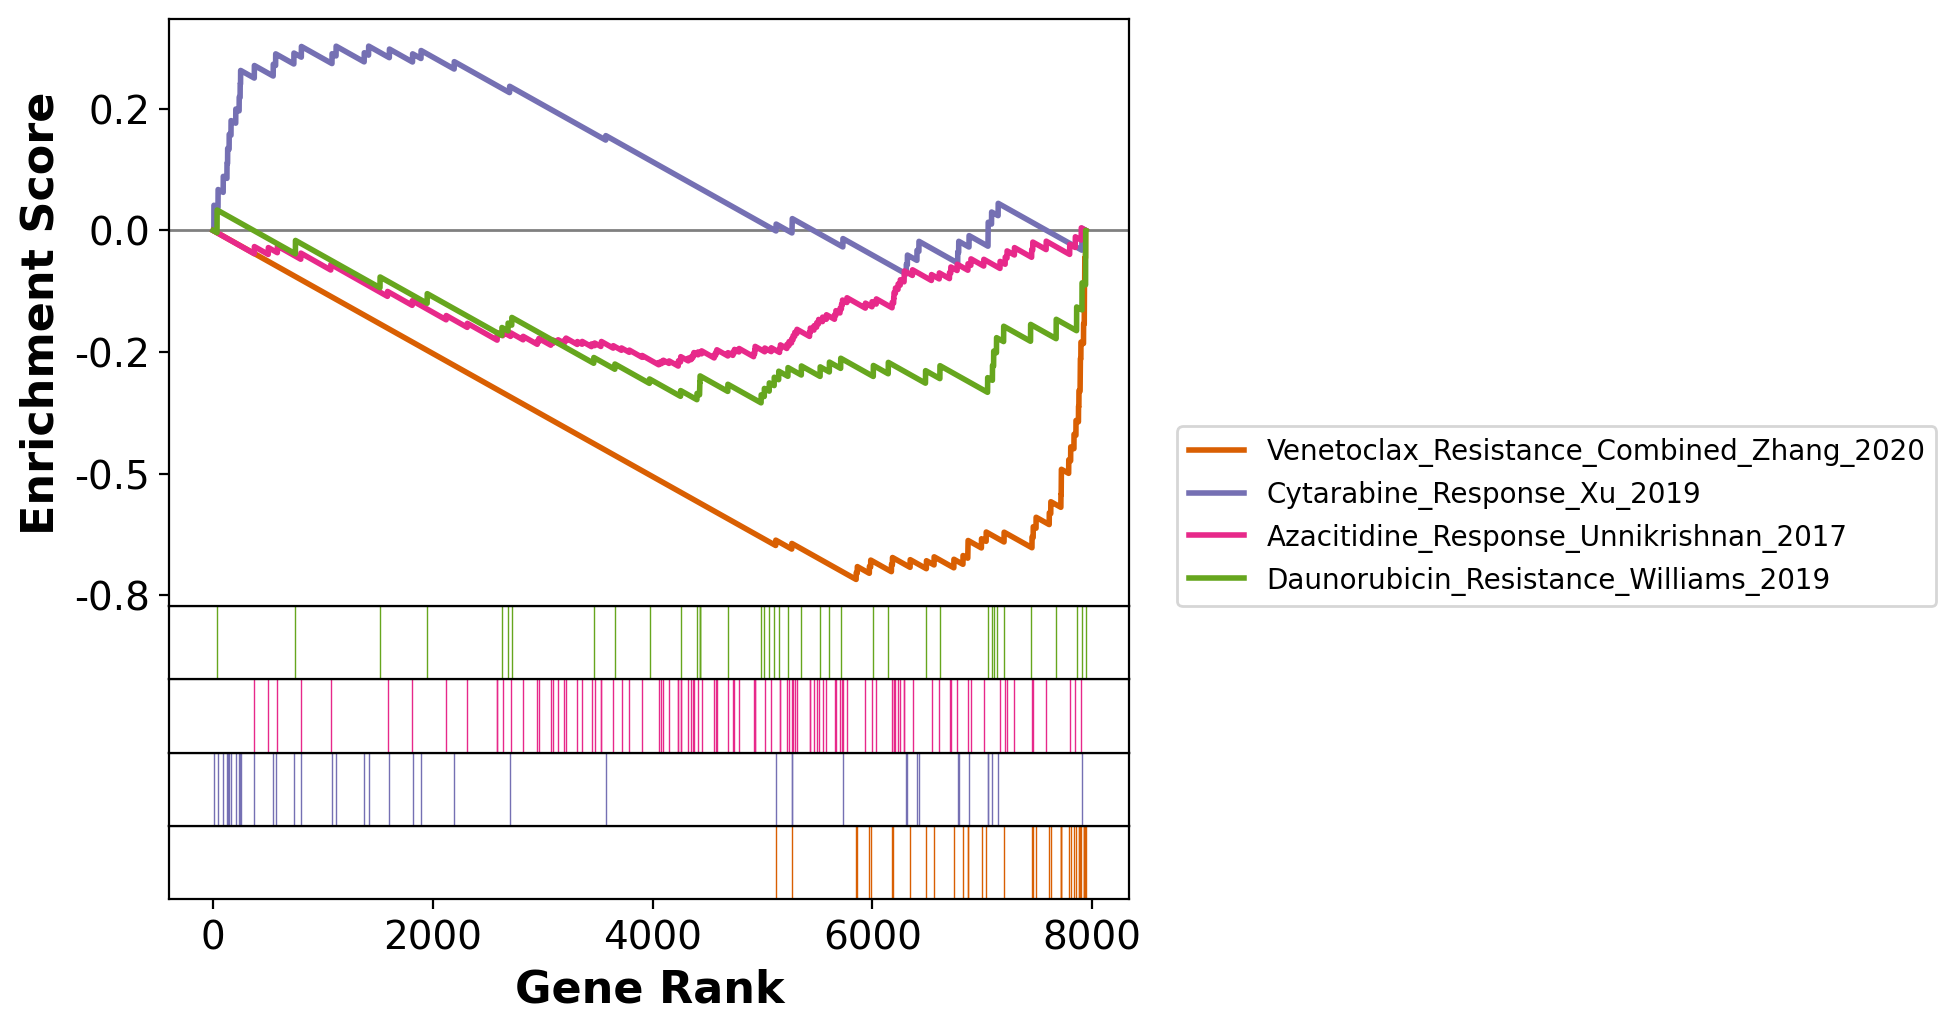

In [22]:
# Select pathways to plot
db = db2
res = gp.prerank(rnk=gene_rank, gene_sets=db, background=bg)
filtered_results = res.res2d[res.res2d['FDR q-val']<0.05]
path = pathlib.Path(db)
path = path.stem

terms = ['Venetoclax_Resistance_Combined_Zhang_2020', 'Cytarabine_Response_Xu_2019',
         'Azacitidine_Response_Unnikrishnan_2017','Daunorubicin_Resistance_Williams_2019']
plt.style.use('default')
cols_1 = ['#d95f02', '#7570b3', '#e7298a', '#66a61e']
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=cols_1)
plt.figure(figsize=(4, 3))
axs = res.plot(terms, show_ranking=False, legend_kws={'loc': (1.05, 0)}, )
axs.savefig(plots + "db2_prenatal_vs_postnatal_selected.png", format='png', bbox_inches='tight')

## Cell Type Deconvolution

In [23]:
# Deconvolution Results
nusvr = pd.read_csv(autogenes, sep='\t', index_col=0)
cellAnnot = cellAnnot.join(color_table)
cellAnnot.to_csv('cellAnnot_signatures.csv')

# Group df
nusvr['signature'] = 'Intermediate'
samples = cellAnnot[cellAnnot["Identity"]=="Prenatal"].index
nusvr.loc[samples, 'signature'] = 'Inferred-Prenatal'

samples = cellAnnot[cellAnnot["Identity"]=="Postnatal"].index
nusvr.loc[samples, 'signature'] = 'Inferred-Postnatal'

nusvr = nusvr[nusvr['signature']!='Intermediate']

# Calculate mean and std err for plotting
grouped_nusvr = nusvr.groupby(by=("signature"))
means = grouped_nusvr.mean().T
errors = grouped_nusvr.sem().T

group1 = nusvr[nusvr['signature']=='Inferred-Prenatal']
group2 = nusvr[nusvr['signature']=='Inferred-Postnatal']

celltypes = nusvr.columns.drop('signature')

In [24]:
# Assign significance scores
pvals = {}

for c in celltypes:

    data_group1 = np.array(group1[c])
    data_group2 = np.array(group2[c])
    
    # Test for equal variance
    levene = stats.levene(data_group1, data_group2, center='mean')
    if levene[1] > 0.05:
        shap1 = stats.shapiro(data_group1)
        shap2 = stats.shapiro(data_group2)
        if shap1[1] > 0.05 and shap2[1] > 0.05:
            t = stats.ttest_ind(a=data_group1, b=data_group2, equal_var=True)
            pvals[c] = [t[1],pval_to_asterisks(t[1]),'eqv_nd']
        else:
            t = stats.ttest_ind(a=data_group1, b=data_group2, equal_var=True)
            pvals[c] = [t[1],pval_to_asterisks(t[1]),'eqv_nnd']
    else:
        shap1 = stats.shapiro(data_group1)
        shap2 = stats.shapiro(data_group2)
        if shap1[1] > 0.05 and shap2[1] > 0.05:
            t = stats.ttest_ind(a=data_group1, b=data_group2, equal_var=False)
            pvals[c] = [t[1],pval_to_asterisks(t[1]),'var_nd']
        else:
            t = stats.ttest_ind(a=data_group1, b=data_group2, equal_var=False)
            pvals[c] = [t[1],pval_to_asterisks(t[1]),'var_nnd']

display(pd.DataFrame(pvals))

,Mono,T,lateEry,cDC,GMP,earlyEry,ProB,CTL,ProMono,NK,ProMono-like,Prog,B,Plasma,pDC,Prog-like,cDC-like,Mono-like,HSC,GMP-like,HSC-like
0,0.574106,0.000032,0.126357,0.240255,0.205908,0.541036,0.390579,0.020925,0.398689,0.289683,0.031261,0.008879,0.036599,0.786673,0.970349,0.838457,0.000254,0.231347,0.000206,0.690669,0.050413
1,ns,****,ns,ns,ns,ns,ns,*,ns,ns,*,**,*,ns,ns,ns,***,ns,***,ns,ns
2,eqv_nnd,eqv_nnd,eqv_nnd,eqv_nnd,eqv_nd,eqv_nd,eqv_nnd,eqv_nnd,eqv_nnd,eqv_nd,eqv_nd,eqv_nd,var_nnd,eqv_nnd,eqv_nnd,eqv_nd,var_nnd,eqv_nnd,eqv_nnd,eqv_nnd,eqv_nd


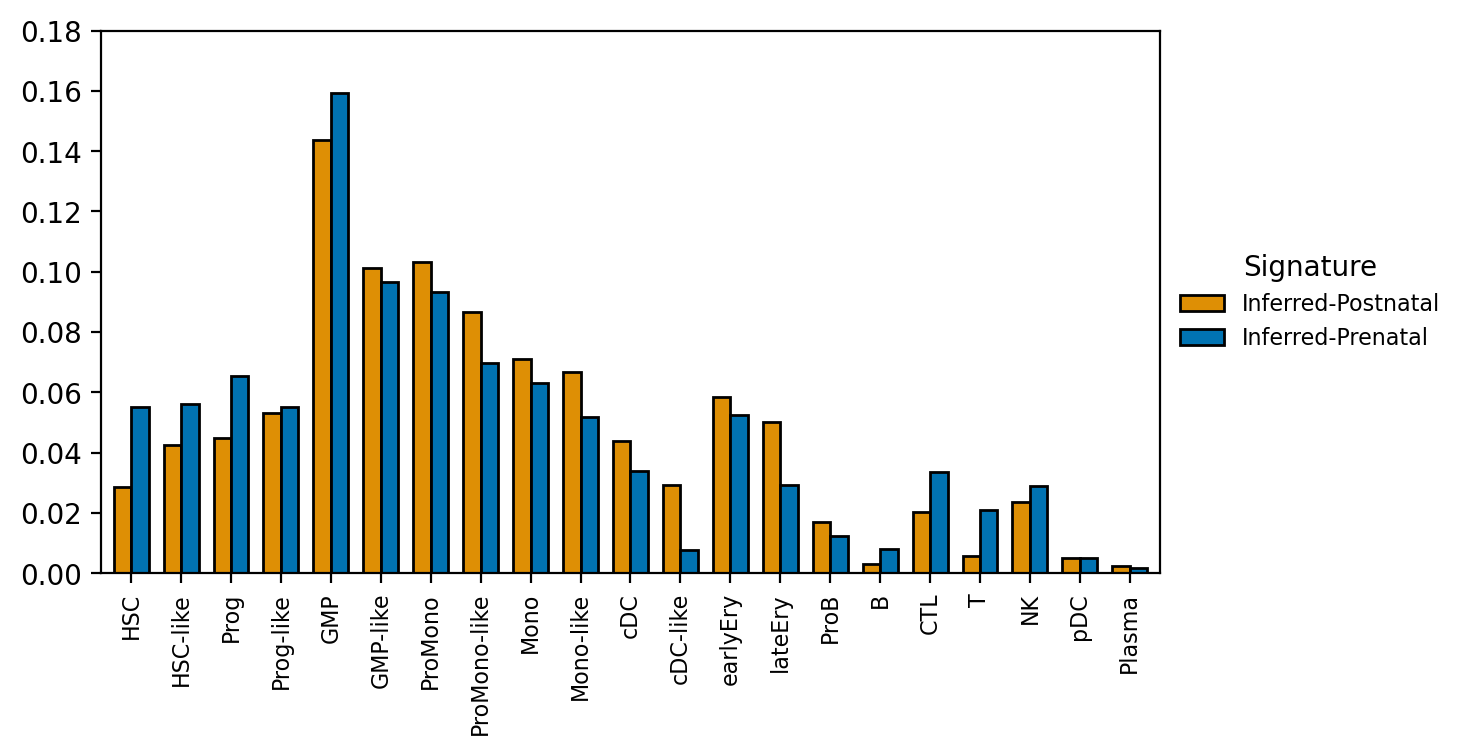

In [25]:
# Plotting
palette_color = {'Inferred-Prenatal':(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
                'Inferred-Postnatal':(0.8705882352941177, 0.5607843137254902, 0.0196078431372549)}

row_order = ['HSC','HSC-like','Prog','Prog-like',
             'GMP','GMP-like','ProMono','ProMono-like',
             'Mono','Mono-like','cDC','cDC-like','earlyEry','lateEry','ProB','B','CTL','T',
             'NK','pDC','Plasma']
means = means.loc[row_order,:]

ax = means.plot.bar(rot=90, color=palette_color, width=0.7, edgecolor = "black", figsize=(6,4))
plt.tight_layout()
plt.grid(False)
legend = ax.legend(title="Signature",
                   loc="center left",
                   fontsize=8,
                   frameon=False,
                   bbox_to_anchor=(1, 0, 0.5, 1))
plt.setp(legend.get_title(),fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=10)
plt.ylim(0, 0.18)
plt.xlabel('', fontsize=10)
plt.savefig(plots + "aml_eto_tcga_deconv.png", dpi=500, format='png', bbox_inches='tight', pad_inches=0.5)